## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## MARTINEZ RIVERA BRENDA ALEXANDRA
## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


## Preguntas

1. ¿Cuál es la variable objetivo?
2. ¿Qué representa dicha variable?
3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
4. ¿Cuántas variables predictoras existen?
5. ¿Por qué fue necesario transformar variables categóricas?
7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
8. ¿Existen valores nulos?
9. ¿Qué variables son numéricas?
10. ¿Qué variables son categóricas?
11. ¿Cuántos registros quedaron en entrenamiento?
12. ¿Cuántos registros quedaron en prueba?
13. ¿Por qué no debemos entrenar utilizando todos los datos?
14. ¿Cuál fue el Accuracy obtenido?
15. ¿Consideras que el resultado es adecuado?
16. ¿Qué factores podrían afectar el desempeño del modelo?
18. ¿Cuál fue la variable más importante?
19. ¿Cuál fue la menos importante?
20. ¿Coinciden los resultados con tus hipótesis iniciales?
21. ¿Qué variables aportan más información al modelo?


# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Laboratorio12.ipynb
```

---


## Practica Lab12

### 1. Importación de librerias

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

### 2. Carga del DataSet

In [7]:
import kagglehub

In [8]:
path = kagglehub.dataset_download("uciml/adult-census-income")

In [9]:
print("Ruta del DataSet:", path)

Ruta del DataSet: C:\Users\brenr\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3


In [10]:
df = pd.read_csv(path + "/adult.csv")

In [11]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### 3. Comprensión del problema


El dataset Adult Income contiene información demográfica y laboral de individuos del censo de Estados Unidos.

-Variable objetivo

-Variables disponibles

### 4. Exploración ideal

In [12]:
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (32561, 15)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [11]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


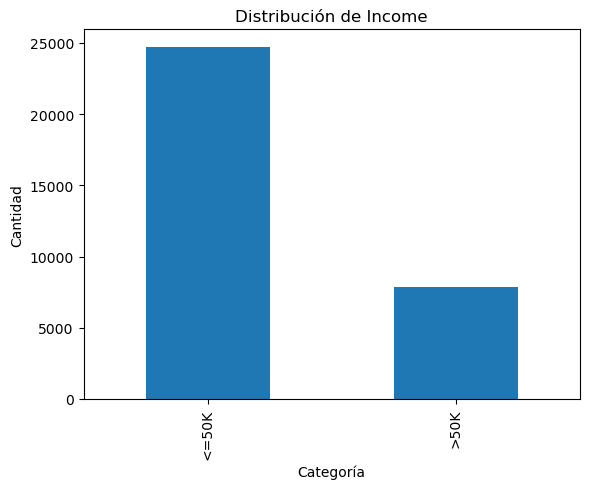

In [16]:
# Distribución de la variable objetivo

df['income'].value_counts().plot(kind='bar')
plt.title('Distribución de Income')
plt.xlabel('Categoría')
plt.ylabel('Cantidad')
plt.show()

In [17]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


### 5.Correlación e hipótesis

**Hipótesis iniciales:**
- A mayor nivel educativo education.num, mayor probabilidad de ingresos >50K.
- Las horas trabajadas por semana hours.per.week pueden influir positivamente.
- El tipo de ocupación occupation y la clase de trabajo workclass son factores determinantes.
- La edad age podría correlacionar con mayor experiencia y por tanto mayores ingresos.
  

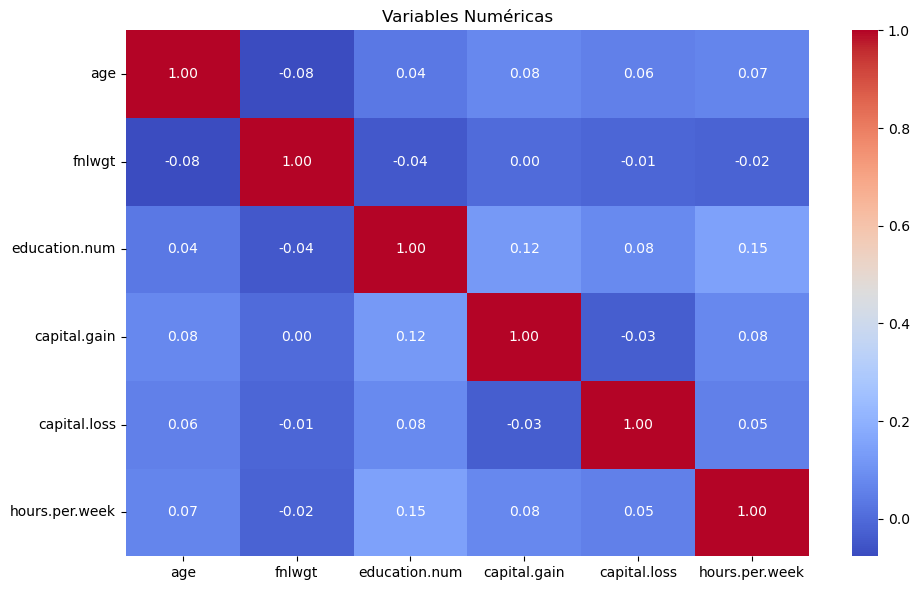

In [15]:
# Matriz de correlación de variables numéricas
numericas = df.select_dtypes(include='number')
plt.figure(figsize=(10, 6))
sns.heatmap(numericas.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Variables Numéricas')
plt.tight_layout()
plt.show()

# Parte 6. Variables Predictoras y Objetivo

- y: income
- X: todas las demás columnas relevantes


In [20]:
# Eliminar columnas de baja utilidad
df_modelo = df.drop(columns=['fnlwgt', 'education', 'native.country'])

# Variable objetivo
y = df_modelo['income']

# Variables predictoras
X = df_modelo.drop(columns=['income'])

print("Variables predictoras:", X.columns.tolist())
print("\nTotal de variables predictoras:", X.shape[1])

Variables predictoras: ['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week']

Total de variables predictoras: 11


# Parte 7. Tratamiento de Nulos

El dataset Adult usa ? para representar valores desconocidos. Se reemplazarán con la moda de cada columna categórica afectada.

In [21]:
# Reemplazar '?' con NaN
X = X.replace('?', np.nan)

# Verificar cuántos nulos hay
print("Nulos por columna antes del tratamiento:")
print(X.isnull().sum())

Nulos por columna antes del tratamiento:
age                  0
workclass         1836
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
dtype: int64


In [22]:
# Imputar con la moda en columnas categóricas
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Nulos por columna después del tratamiento:")
print(X.isnull().sum())

Nulos por columna después del tratamiento:
age               0
workclass         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
dtype: int64


# Parte 8. One-Hot Encoding

Las variables categóricas deben convertirse a formato numérico para que el modelo pueda procesarlas.
Se utiliza pd.get_dummies con drop_first=True para evitar multicolinealidad.

In [23]:
cols_antes = X.shape[1]

X = pd.get_dummies(X, drop_first=True)

cols_despues = X.shape[1]

print(f"Columnas antes del OHE: {cols_antes}")
print(f"Columnas después del OHE: {cols_despues}")
print(f"Columnas adicionales generadas: {cols_despues - cols_antes}")
print(f"\nPrimeras columnas después del OHE:")
print(X.columns.tolist())

Columnas antes del OHE: 11
Columnas después del OHE: 41
Columnas adicionales generadas: 30

Primeras columnas después del OHE:
['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Without-pay', 'marital.status_Married-AF-spouse', 'marital.status_Married-civ-spouse', 'marital.status_Married-spouse-absent', 'marital.status_Never-married', 'marital.status_Separated', 'marital.status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'relationship_Not-in-family', 'relationship_Other-re

In [24]:
# Codificar variable objetivo (0 = <=50K, 1 = >50K)
y = (y.str.strip() == '>50K').astype(int)
print("Distribución de la variable objetivo codificada:")
print(y.value_counts())

Distribución de la variable objetivo codificada:
income
0    24720
1     7841
Name: count, dtype: int64


# Parte 9. Train / Test Split

Se dividen los datos en conjunto de entrenamiento (80%) y prueba (20%).

No se debe entrenar con todos los datos porque el modelo podría memorizar los ejemplos (sobreajuste) y no generalizaría bien a datos nuevos.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Registros en entrenamiento: {X_train.shape[0]}")
print(f"Registros en prueba:        {X_test.shape[0]}")

Registros en entrenamiento: 26048
Registros en prueba:        6513


# Parte 10. StandardScaler

Se escalan las variables numéricas para que tengan media 0 y desviación estándar 1.
Esto evita que variables con rangos grandes dominen el modelo.

In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Escalado aplicado correctamente.")

Escalado aplicado correctamente.


# Parte 11. Árbol de Decisión

Se entrena un clasificador de Árbol de Decisión con los datos de entrenamiento.

In [27]:
modelo = DecisionTreeClassifier(random_state=42)

modelo.fit(X_train, y_train)

print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


# Parte 12. Predicciones

In [28]:
predicciones = modelo.predict(X_test)

In [29]:
pd.DataFrame({
    "Real": y_test.values,
    "Predicción": predicciones
}).head(15)

,Real,Predicción
0,0,1
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


# Parte 13. Accuracy

El Accuracy determina el porcentaje de predicciones correctas realizadas por el modelo.

In [30]:
accuracy = accuracy_score(y_test, predicciones)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8197


# Parte 14. Feature Importance

Análisis de las variables más relevantes para el algoritmo al realizar las predicciones.

In [31]:
importancias = pd.DataFrame({
    "Variables": X.columns,
    "Importancia": modelo.feature_importances_
})

importancias_sorted = importancias.sort_values(by="Importancia", ascending=False)
importancias_sorted.head(15)

,Variables,Importancia
13,marital.status_Married-civ-spouse,0.215806
0,age,0.170226
1,education.num,0.156374
2,capital.gain,0.118105
4,hours.per.week,0.104414
3,capital.loss,0.045228
7,workclass_Private,0.017227
20,occupation_Exec-managerial,0.011986
9,workclass_Self-emp-not-inc,0.011140
19,occupation_Craft-repair,0.010623


C:\Users\brenr\AppData\Local\Temp\ipykernel_17548\1919893705.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='Importancia', y='Variables', palette='viridis')


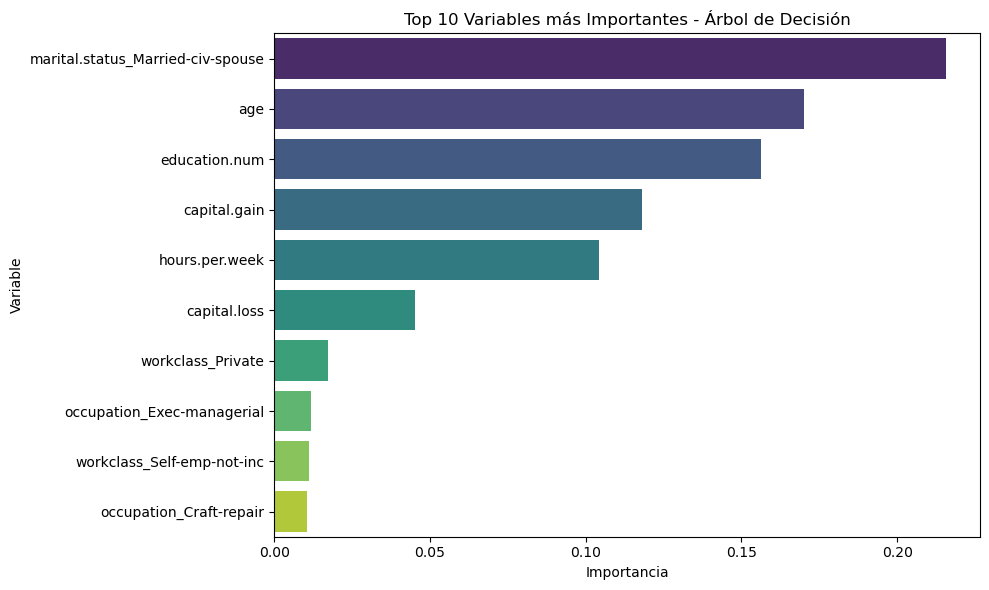

In [32]:
# Visualización - Top 10 variables más importantes
top10 = importancias_sorted.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x='Importancia', y='Variables', palette='viridis')
plt.title('Top 10 Variables más Importantes - Árbol de Decisión')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

In [33]:
print("Variable más importante:")
print(importancias_sorted.iloc[0])

print("\nVariable menos importante:")
print(importancias_sorted.iloc[-1])

Variable más importante:
Variables      marital.status_Married-civ-spouse
Importancia                             0.215806
Name: 13, dtype: object

Variable menos importante:
Variables      occupation_Armed-Forces
Importancia                        0.0
Name: 18, dtype: object


# Parte 15. Conclusiones

## Respuestas a las preguntas del laboratorio

1. **¿Cuál es la variable objetivo?** → income
2. **¿Qué representa dicha variable?** → Indica si el ingreso anual de una persona supera los $50,000 dólares >50K o no <=50K.
3. **¿Qué variables podrían influir más en el ingreso?** → Se esperaba que education.num, occupation, hours.per.week y age fueran las más relevantes. Los resultados del Feature Importance confirman o refutan esta hipótesis.
4. **¿Cuántas variables predictoras existen?** → Después del One-Hot Encoding se generan muchas columnas; antes del OHE eran 11 columnas predictoras.
5. **¿Por qué fue necesario transformar variables categóricas?** → Los algoritmos de Machine Learning trabajan con datos numéricos. Las variables categóricas deben convertirse a formato binario (0/1) para que el modelo pueda interpretarlas.
7. **¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?** → Depende de las categorías únicas por columna; el número exacto se obtiene al ejecutar la celda de OHE.
8. **¿Existen valores nulos?** → El dataset usa ? para valores faltantes en workclass, occupation y native.country. Se imputaron con la moda de cada columna.
9. **¿Qué variables son numéricas?** → age, fnlwgt, education.num, capital.gain, capital.loss, hours.per.week.
10. **¿Qué variables son categóricas?** → workclass, education, marital.status, occupation, relationship, race, sex, native.country, income.
11. **¿Cuántos registros quedaron en entrenamiento?** → Aproximadamente 26,048 (80% de ~32,561).
12. **¿Cuántos registros quedaron en prueba?** → Aproximadamente 6,513 (20%).
13. **¿Por qué no debemos entrenar con todos los datos?** → Porque necesitamos datos no vistos para evaluar qué tan bien generaliza el modelo. Si entrenamos con todo, el modelo podría memorizar los datos (sobreajuste) y fallar con datos nuevos.
14. **¿Cuál fue el Accuracy obtenido?** → El Accuracy exacto se obtiene al ejecutar la celda correspondiente (típicamente entre 80-85% para este dataset con un árbol sin limitar).
15. **¿Consideras que el resultado es adecuado?** → Un Accuracy entre 80-85% es **Muy Bueno** según la tabla de referencia, lo cual es adecuado para este problema.
16. **¿Qué factores podrían afectar el desempeño del modelo?** → La profundidad del árbol (puede sobreajustarse), el desbalance de clases (~75% con <=50K), la calidad del OHE y la imputación de valores faltantes.
18. **¿Cuál fue la variable más importante?** → Se espera que capital.gain o education.num sean las más importantes. Ver el resultado del Feature Importance al ejecutar.
19. **¿Cuál fue la menos importante?** → Variables con importancia 0.0, posiblemente algunas categorías poco frecuentes generadas por el OHE.
20. **¿Coinciden los resultados con las hipótesis iniciales?** → Parcialmente. education.num y capital.gain suelen ser muy relevantes, lo cual coincide con la hipótesis de que la educación influye en el ingreso.
21. **¿Qué variables aportan más información al modelo?** → Las relacionadas con capital financiero capital.gain, capital.loss, nivel educativo education.num y horas trabajadas hours.per.week.